In [7]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots
using Measures

Simulate the dynamics of the spinful Hubbard model on a 2D lattice of $N_x \times N_y$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{\langle i,j\rangle, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{j, \sigma}+\hat{c}_{j, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [8]:
N_x = 6
N_y = 1
N_spinful_sites = N_x * N_y
t = 1.0
U = 8.0

8.0

Get 2D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [9]:
topo = rectangletopology(N_x, N_y)

imag_circ = []
imag_thetas = []

H = MajoranaSum(Float64, N_spinful_sites, true)

dt = 0.02

#up hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopup, [i, j]))
    push!(imag_thetas, t * dt)
    H += MajoranaSum(N_spinful_sites, :hopup, [i, j]) * (-t)
end

#down hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopdn, [i, j]))
    push!(imag_thetas, t * dt)
    H += MajoranaSum(N_spinful_sites, :hopdn, [i, j]) * (-t)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(imag_circ, ImaginaryFermionicGate(:nupndn, [i]))
    push!(imag_thetas, - U * dt)
    # t1 = MajoranaSum(N_spinful_sites, :nup, [i])
    # t2 = MajoranaSum(N_spinful_sites, :ndn, [i])
    # MajoranaPropagation.pop_id!(t1)
    # MajoranaPropagation.pop_id!(t2)
    # H_term = t1 * t2 * U
    # H += H_term
    H += MajoranaSum(N_spinful_sites, :nupndn, [i]) * U
end

Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [10]:
target_beta = 2
n_layers = Int(round(target_beta / dt))

min_abs_coeff = 5e-4

obs = MajoranaSum(N_spinful_sites, true, Dict(getinttype(N_spinful_sites*2)(0) => 1.0))
obs = VectorMajoranaSum(obs)
@show obs 

res = zeros(n_layers+1)
res[1] = MajoranaPropagation.scalarproduct(H, obs)
length_res = zeros(Int, n_layers+1)
length_res[1] = length(obs)

for l in 1:n_layers
    propagate!(imag_circ, obs, imag_thetas; min_abs_coeff, heisenberg=false, truncate_each_mr=true, normalize_coeffs=true)
    res[l+1] = MajoranaPropagation.scalarproduct(H, obs)
    length_res[l+1] = length(obs)
end 
obs

obs = VectorMajoranaSum with 1 term:
1.0 * 000000000000000000000000



VectorMajoranaSum with 155334 terms:
1.0 * 000000000000000000000000
-0.43864196958645607 * 110000000000000000000000
-0.41854926656273067 * 001100000000000000000000
0.1367249768711088 * 111100000000000000000000
-0.3640244940741291 * 010010000000000000000000
-0.3344469146320973 * 011110000000000000000000
0.36298580874341185 * 100001000000000000000000
0.33404251353718634 * 101101000000000000000000
-0.44164841862548754 * 000011000000000000000000
-0.02403447141521455 * 110011000000000000000000
-0.12455982800927895 * 001111000000000000000000
-0.2868729570808228 * 111111000000000000000000
-0.37362068674330257 * 000100100000000000000000
-0.3461641969283232 * 110100100000000000000000
0.008370232696529228 * 101010100000000000000000
0.01784817720957509 * 010110100000000000000000
0.004218718768635918 * 011001100000000000000000
-0.011284616241427023 * 100101100000000000000000
-0.3286013234704227 * 000111100000000000000000
0.3015893821876153 * 110111100000000000000000
  ...


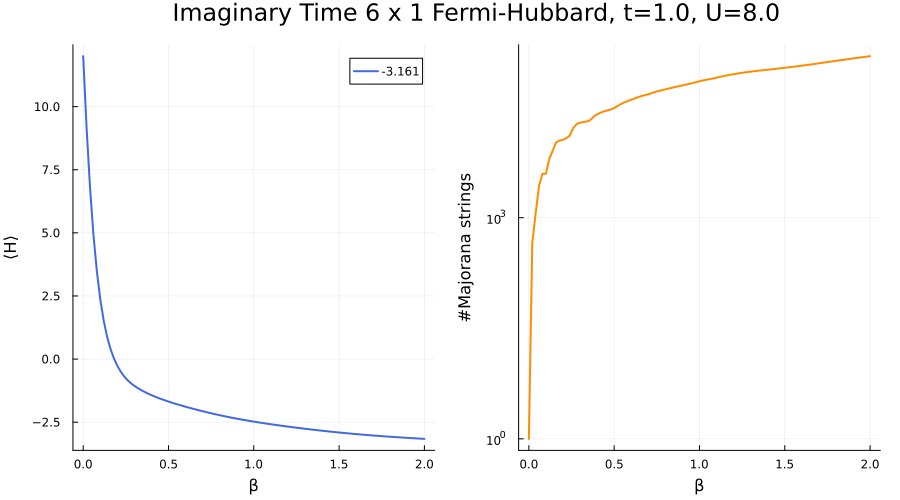

In [11]:
p_res = plot(dt*(0:n_layers)./ t, res, label=round(res[end], digits=3), xlabel="β", ylabel="⟨H⟩", lw=2, color=:royalblue)
p_length = plot(dt*(0:n_layers)./ t, length_res, label="", xlabel="β", ylabel="#Majorana strings", yscale=:log10, lw=2, color=:darkorange)    

plot(p_res, p_length, layout=(1,2), size=(900,500), margin=3mm, suptitle="Imaginary Time $N_x x $N_y Fermi-Hubbard, t=$t, U=$U")